# Day 2: Pandas, Reading Real CSV Files & Basic Plotting

**Before you start:** make sure `dmi_all.csv` and `nino34.csv` are in the
same folder as this notebook.

A note on scope: 
- today's plotting is **quick and exploratory** — just enough to look at your
data as you work. Proper figure-making (multi-panel layouts, maps with Cartopy, publication-
quality styling) is its own full day later this week.
- today's CSV data is station (point) data. Gridded data (NetCDF, model/reanalysis output) is what xarray is for — that's
tomorrow.


---
## Demo — Part A: Why pandas?

You already know NumPy arrays from yesterday. Pandas builds on top of NumPy but adds three
things that matter constantly in real data work:

- **Labels** — rows and columns have names, not just positions
- **Native handling of dates** — a first-class datetime index, with resampling
- **Mixed types and built-in missing-data handling** — a single table can have numbers,
  strings, and dates together, with NaN handled consistently throughout


---
### Topic 1 - Pandas

***reading files***
- reading csv files with modalities
- basic Pandas concepts - dataframe, series

***operations on time***
- creation of time series of dates - pd.date_range()
- conversion between pandas datetime and Timestamp pd.to_datetime()
- date offsets  - resetting dates to monthEnd, monthBegin - we need it to match different data

***operations on time index***
- selecting data for year, month, quarter
- resampling over time - daily to monthly, quarterly, annual + resample offsets (hydrological year)
- groupby (day of year, month) - towards climatology
- smoothing - rolling - including applying custom functions on a rolling window

### Topic 2 - plotting (2D data)
- plotting "normal" figures - time series, scatterplot, barplot
- manipulating lines and points - colours, transparency
- formatting dates in xaxis
- formatting ticks and tick labels
- legends

---
### Reading CSV files

In [18]:
import pandas as pd
import numpy as np

# Here we will open a csv file dmi_all.csv
# inspect the csv data (open the file in Excel or in text editor). 
# What is the structure of the file? 
# What is in columns, what is in rows? 
# What is in the first row? what is in the first column?
# 
# note the that the command below considers the first column to store an index, and will read that index as dates 
# note that read_csv() function has a rich functionality and many parameters that can be set to make it read a file with a particular format
df=pd.read_csv("pr_mon_madagascar.csv",parse_dates=True,index_col=0)
df

,ANTANANARIVO,TOAMASINA,ANTSOHIHY
date,,,
1986-01-01,266.2,199.9,421.3
1986-02-01,300.1,391.2,187.8
1986-03-01,165.0,563.6,85.8
1986-04-01,30.6,342.4,91.3
1986-05-01,17.7,310.6,18.7
...,...,...,...
2023-08-01,0.0,0.0,0.0
2023-09-01,8.4,112.3,7.7
2023-10-01,130.3,287.3,47.1


In [19]:
# showing index only
df.index

DatetimeIndex(['1986-01-01', '1986-02-01', '1986-03-01', '1986-04-01',
               '1986-05-01', '1986-06-01', '1986-07-01', '1986-08-01',
               '1986-09-01', '1986-10-01',
               ...
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
               '2023-11-01', '2023-12-01'],
              dtype='datetime64[us]', name='date', length=456, freq=None)

In [20]:
# You can use head, describe, info, columns commands to explore the data
print(df.head())
print(df.head(2))
print(df.describe())
print(df.columns)
print(df.info())

            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-01-01         266.2      199.9      421.3
1986-02-01         300.1      391.2      187.8
1986-03-01         165.0      563.6       85.8
1986-04-01          30.6      342.4       91.3
1986-05-01          17.7      310.6       18.7
            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-01-01         266.2      199.9      421.3
1986-02-01         300.1      391.2      187.8
       ANTANANARIVO   TOAMASINA   ANTSOHIHY
count    456.000000  456.000000  456.000000
mean     112.824781  266.256579  118.751096
std      136.880330  155.412862  150.454956
min        0.000000    0.000000    0.000000
25%        6.200000  151.325000    0.000000
50%       39.850000  227.900000   39.350000
75%      197.575000  343.350000  214.375000
max      614.200000  994.200000  709.700000
Index(['ANTANANARIVO', 'TOAMASINA', 'ANTSOHIHY'], dtype='str')
<class 'pandas.DataFrame

In [21]:
#this exposes the underlying numpy array
df.values

array([[266.2, 199.9, 421.3],
       [300.1, 391.2, 187.8],
       [165. , 563.6,  85.8],
       ...,
       [130.3, 287.3,  47.1],
       [101.2, 165.1,  50.4],
       [173.6, 207.1, 206.8]], shape=(456, 3))

### Selecting data: columns,`.loc`, `.iloc`

In [22]:
# Let's extract just one column
#note that there is a difference between these two commands

#this one extracts data frame with two dimensions
pr_tana=df[["ANTANANARIVO"]]
print(pr_tana.shape)

#this one extracts a series with one dimension only
pr_tana=df["ANTANANARIVO"]
print(pr_tana.shape)

(456, 1)
(456,)


In [23]:
#note that the direct selection by label selects only from dataframe columns, trying to select a particular date will give an error
#df["1990-06-01"]

# but this will work:
print(df["1990-06-01":"2000-06-01"])

#this will work too - note that the year has to be given as string, not as an integer!
print(df["1990":"2000"])

            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1990-06-01           0.0      191.5        0.0
1990-07-01           5.8      229.5        0.0
1990-08-01           0.0      153.0        0.0
1990-09-01           0.0       92.9        9.1
1990-10-01          74.7      115.4       15.6
...                  ...        ...        ...
2000-02-01         219.3      497.5      279.0
2000-03-01         161.9      616.9      103.1
2000-04-01          17.6      180.9       58.7
2000-05-01           6.0      133.8        5.1
2000-06-01           0.0      183.4        0.0

[121 rows x 3 columns]
            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1990-01-01         331.7      168.9      347.0
1990-02-01         213.8      382.3      351.5
1990-03-01         104.0      194.3       49.4
1990-04-01          55.4      588.0      299.9
1990-05-01           8.2      217.3       12.7
...                  ...        ... 

In [24]:
#two properties give more control in selecting data

# .loc -- select by LABEL
print(df.loc["1990-06-01","TOAMASINA"])

#now we can select a particular date
print(df.loc["1990-06-01"])

# .iloc -- select by POSITION (like NumPy)
print(df.iloc[0, 0])

191.5
ANTANANARIVO      0.0
TOAMASINA       191.5
ANTSOHIHY         0.0
Name: 1990-06-01 00:00:00, dtype: float64
266.2


### Dates in pandas 

In [25]:
# above we have read data with dates embedded into the file. But it is sometimes necessary to create dates in code

# You can create your own date list and convert this to 
# a pandas datetime series
dates = ["2025-01-12", "2025-02-05", "2025-03-04"]
dates = pd.to_datetime(dates, format="%Y-%m-%d")
dates

DatetimeIndex(['2025-01-12', '2025-02-05', '2025-03-04'], dtype='datetime64[us]', freq=None)

In [26]:
# create series "automatically" - date range should be intuitive
dates = pd.date_range("2025-01-01", periods=5, freq='D')
print(dates)

dates = pd.date_range("2025-01-01", "2026-01-01", freq='D')
print(dates)


DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05'],
              dtype='datetime64[us]', freq='D')
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-23', '2025-12-24', '2025-12-25', '2025-12-26',
               '2025-12-27', '2025-12-28', '2025-12-29', '2025-12-30',
               '2025-12-31', '2026-01-01'],
              dtype='datetime64[us]', length=366, freq='D')


In [27]:
# offsetting dates
# sometimes it is necessary to shift dates by some amount of time
print(dates + pd.offsets.DateOffset(weeks=2))

print(dates + pd.offsets.DateOffset(days=2))

#set dates at the beginning of the month
# note that this shifts dates to be beginning of the NEXT month
print(dates + pd.offsets.MonthBegin())

#this will shift them to the beginning of THIS month, unless the date is already on the first of the month 
# - then it will shift it to the beginning of the PREVIOUS month 
print(dates - pd.offsets.MonthBegin())

#set dates at the end of the month
print(dates + pd.offsets.MonthEnd())


DatetimeIndex(['2025-01-15', '2025-01-16', '2025-01-17', '2025-01-18',
               '2025-01-19', '2025-01-20', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24',
               ...
               '2026-01-06', '2026-01-07', '2026-01-08', '2026-01-09',
               '2026-01-10', '2026-01-11', '2026-01-12', '2026-01-13',
               '2026-01-14', '2026-01-15'],
              dtype='datetime64[us]', length=366, freq=None)
DatetimeIndex(['2025-01-03', '2025-01-04', '2025-01-05', '2025-01-06',
               '2025-01-07', '2025-01-08', '2025-01-09', '2025-01-10',
               '2025-01-11', '2025-01-12',
               ...
               '2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
               '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01',
               '2026-01-02', '2026-01-03'],
              dtype='datetime64[us]', length=366, freq=None)
DatetimeIndex(['2025-02-01', '2025-02-01', '2025-02-01', '2025-02-01',
               '2025-02-01'

In [28]:
# towards applications:
# Offsetting date in a data frame so that df_dmi index is at the end of the month
# we create a new date from index
newdate = df.index +pd.offsets.MonthEnd()

#copying our data into a new data frame
newdf=df.copy()

#and then replace the index with that new date
newdf.index=newdate
print(newdf)

            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-01-31         266.2      199.9      421.3
1986-02-28         300.1      391.2      187.8
1986-03-31         165.0      563.6       85.8
1986-04-30          30.6      342.4       91.3
1986-05-31          17.7      310.6       18.7
...                  ...        ...        ...
2023-08-31           0.0        0.0        0.0
2023-09-30           8.4      112.3        7.7
2023-10-31         130.3      287.3       47.1
2023-11-30         101.2      165.1       50.4
2023-12-31         173.6      207.1      206.8

[456 rows x 3 columns]


### Selecting data by dates

In [29]:
#selecting data
#we know slicing already
df["1990-01-01":"1990-12-31"]

#but we can also select data for a particular month
print(df[df.index.month==12])

#or year
print(df[df.index.year==2010])


            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-12-01         272.3      505.6      401.7
1987-12-01          99.8       91.0      167.8
1988-12-01         224.5      434.4      377.0
1989-12-01         366.8      657.7      203.8
1990-12-01         206.3      422.3      221.5
1991-12-01         171.3      264.7      232.1
1992-12-01         123.1       51.8      118.0
1993-12-01         261.9      352.9      171.1
1994-12-01         219.5      270.1      158.7
1995-12-01         292.4      512.9      390.7
1996-12-01         327.9      577.7      281.1
1997-12-01         394.8      525.0      165.6
1998-12-01         515.3      387.7      175.5
1999-12-01         169.8      180.5      166.2
2000-12-01         282.4      302.4      233.2
2001-12-01         295.9      356.1      169.9
2002-12-01         277.6      532.7      260.7
2003-12-01         175.3      197.0      374.8
2004-12-01         347.1      653.7      223.4
2005-12-01   

### Operations on time axis - aggregation in time

In [30]:
# Resampling: aggregate to a coarser time frequency - monthly
monthly_mean = df.resample("ME").mean()   # "ME" = month end
print(monthly_mean.head())

# aggregating to quarterly data
#this will be for "calendar" year quarters
quarterly_mean=df.resample("QE").mean() # "QE" = end of the quarter
print(quarterly_mean)

#and this will be for climatological quarters
quarterly_mean_clim=df.resample("QE-NOV").mean() # "QE-NOV" = end of the quarter, with quarter ending at the end of November
print(quarterly_mean_clim)

#aggregating to yearly with index date set at the end of the year
yearly_mean = df.resample("YE").mean()    # "YE" = year end
print(yearly_mean)

#aggregating to yearly, but with index date at the beginning of the year
yearly_sum = df.resample("YS").sum()    # "YS" = year start
print(yearly_sum)

# Resample to yearly, so that year ends in June, i.e year goes from July-Jun
print(df.resample("YE-JUN").mean())

# Resample to yearly, so that year starts on 1 July, i.e year goes from July-Jun
print(df.resample("YS-JUL").mean())


            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-01-31         266.2      199.9      421.3
1986-02-28         300.1      391.2      187.8
1986-03-31         165.0      563.6       85.8
1986-04-30          30.6      342.4       91.3
1986-05-31          17.7      310.6       18.7
            ANTANANARIVO   TOAMASINA   ANTSOHIHY
date                                            
1986-03-31    243.766667  384.900000  231.633333
1986-06-30     16.100000  284.066667   36.666667
1986-09-30      6.366667  156.333333    3.033333
1986-12-31    190.266667  379.866667  182.333333
1987-03-31    280.133333  395.066667  307.100000
...                  ...         ...         ...
2022-12-31    149.300000   88.633333  112.166667
2023-03-31    348.133333  372.866667  311.700000
2023-06-30     31.366667  272.133333   40.733333
2023-09-30      2.800000   87.700000    2.566667
2023-12-31    135.033333  219.833333  101.433333

[152 rows x 3 columns]
          

### Intoducting Pandas plotting

<Axes: xlabel='date'>

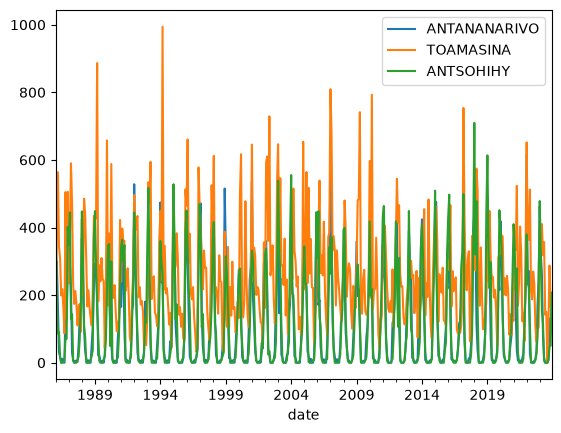

In [31]:
# pandas data can simply be plotted in a "quick and dirty" way as follows:
# this reads plot data and paramters from the dataframe and plots a "basic" plots
df.plot()

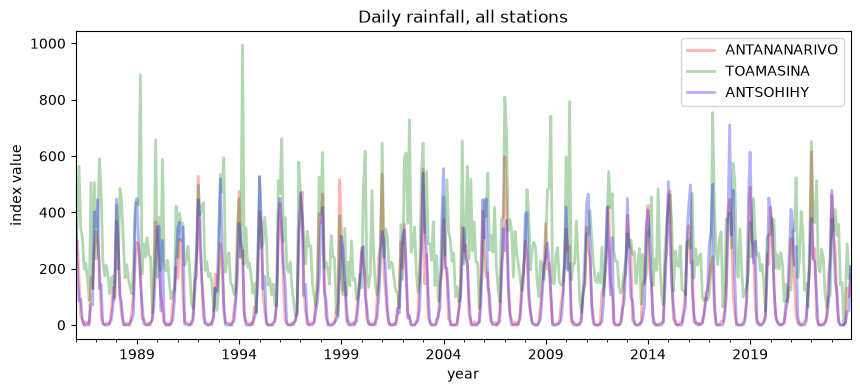

In [32]:
# plot can be customized a little:
# Simple, customized plot

import matplotlib.pyplot as plt
df.plot(figsize=(10, 4), title="Daily rainfall, all stations", alpha=0.3, ylabel="index value", xlabel="year", linewidth=2, color=["red","green", "blue"])
plt.show()


### Groupby operation ###

<Axes: xlabel='date'>

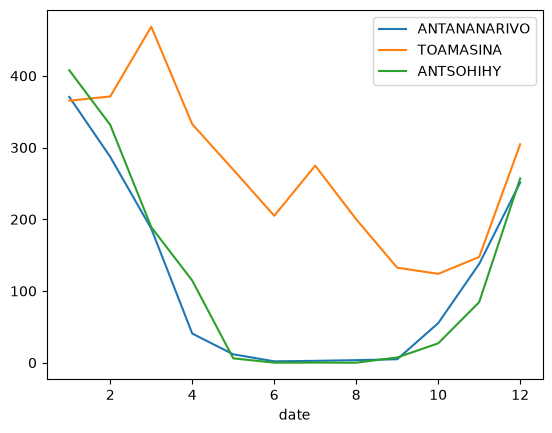

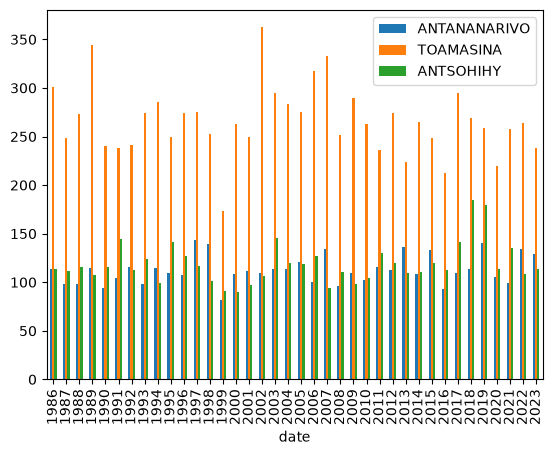

In [34]:
# Using groupby to create a monthly climatology

clim=df.groupby(df.index.month).mean()
clim.plot()

#calculating annual mean
annual_mean = df.groupby(df.index.year).mean()
annual_mean.plot(kind="bar")


### Towards real life applications

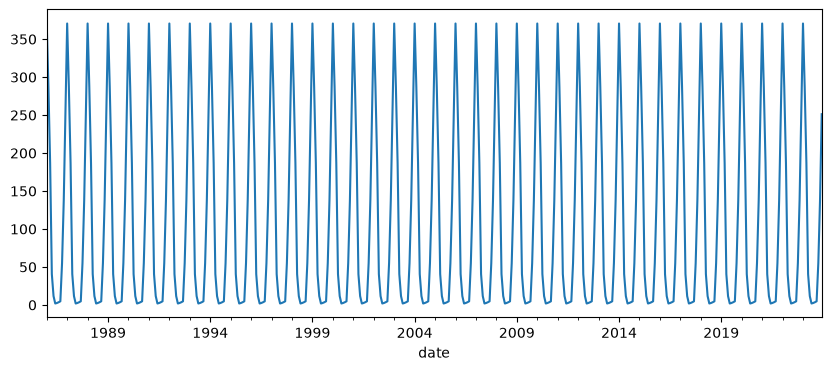

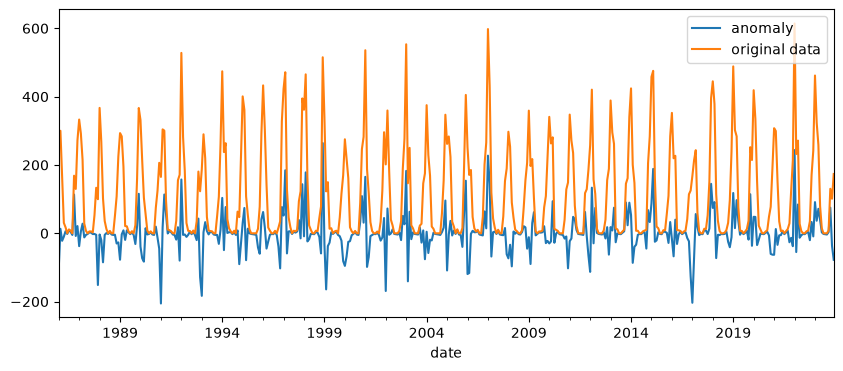

In [22]:
#calculating anomalies from climatology

#.transform() function "transforms" the groupby onto the original time series
climts=df.groupby(df.index.month).transform("mean")
climts["ANTANANARIVO"].plot(figsize=(10, 4))
plt.show()

#we can now subtract that time series of climatology from the original time series to calculate anomalies
anomts=df-climts

anomts["ANTANANARIVO"].plot(label="anomaly", figsize=(10, 4))
df["ANTANANARIVO"].plot(label="original data")
plt.legend()


<Axes: xlabel='date'>

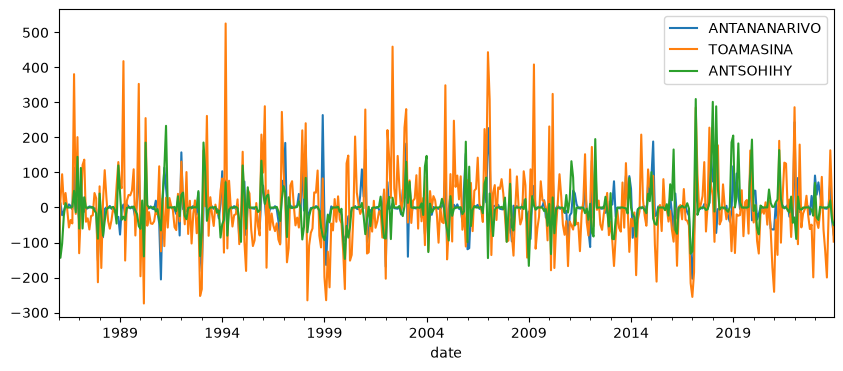

In [23]:
#alternative way of calculating climatology - using lambda function
# lambda function is applied on each group
# we can skip calculating climatology all together, and calculate anomaly immediately
anom_ts=df.groupby(df.index.month).transform(lambda x: x-x.mean())
anom_ts.plot(figsize=(10, 4))

<Axes: xlabel='date'>

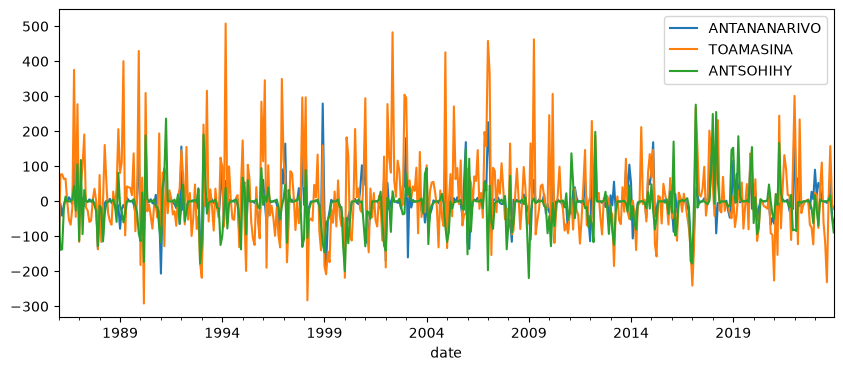

In [24]:
#this is particularly useful as it allows for setting up a reference period like so:
anom_ts=df.groupby(df.index.month).transform(lambda x: x-x["2010":"2020"].mean())
anom_ts.plot(figsize=(10, 4))

---
## Extra topics

### Smoothing data: rolling mean

            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-12-31           NaN        NaN        NaN
1987-12-31           NaN        NaN        NaN
1988-12-31           NaN        NaN        NaN
1989-12-31           NaN        NaN        NaN
1990-12-31       1244.04     3379.8    1350.44
            ANTANANARIVO  TOAMASINA  ANTSOHIHY
date                                          
1986-12-31           NaN        NaN        NaN
1987-12-31           NaN        NaN        NaN
1988-12-31       1244.04    3379.80    1350.44
1989-12-31       1221.20    3228.64    1425.02
1990-12-31       1263.00    3211.60    1429.30


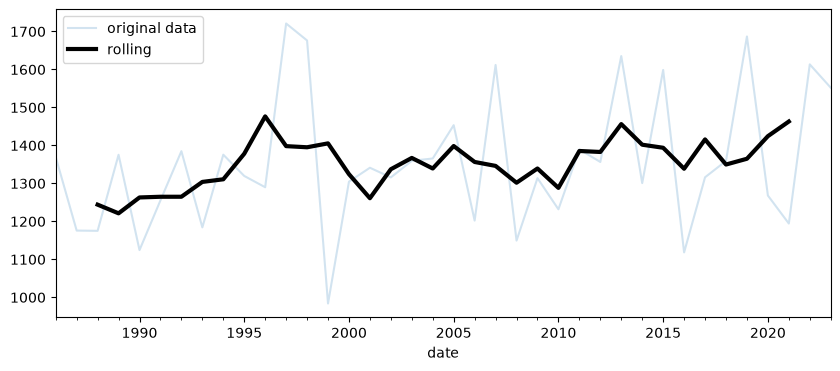

In [25]:
# Rolling windows: e.g. a 3-yearly mean
#dated on the last day of the 5-year period
# let's do it on annual ratther than monthly data

df_year=df.resample("YE").sum()

roll_5Y = df_year.rolling(window=5).mean()
print(roll_5Y.head(5))

#Dated on the center of the moving window - note that the day is not set to the middle of the month, though
roll_5Y = df_year.rolling(window=5, center=True).mean()
print(roll_5Y.head(5))

#let's make a bit more complicated plot
#adding labels

df_year["ANTANANARIVO"].plot(label="original data", figsize=(10, 4), alpha=0.2)
roll_5Y["ANTANANARIVO"].plot(label="rolling", linewidth=3, color="black")
#and forcing the plot to show legend
plt.legend()

### Last but not least - dealing with climatological seasons

In [26]:
# to calculate data for climatological seasons - we can use group by but...
# this will group by calendar quarters
df.groupby(df.index.quarter).mean()

# so to groupby DJF, MAM, JJA and SON seasons we need to do some "gymnastics"

#this will group by climatological quarters
# but note that seasons are denoted by numbers 1 to 4 which might be a bit confusing - which is the season 1?
df.groupby((df.index + pd.DateOffset(months=1)).quarter).mean()


,ANTANANARIVO,TOAMASINA,ANTSOHIHY
date,,,
1,302.943860,347.067544,332.126316
2,79.778947,356.800000,103.252632
3,2.686842,226.546491,0.058772
4,65.889474,134.612281,39.566667


In [27]:
# an alternative is to resample to seasonal means
temp=df.resample("QE-NOV").mean()
# and then group by month
#note that now we will have the seasons marked by the end month
temp=temp.groupby(temp.index.month).mean()
temp

,ANTANANARIVO,TOAMASINA,ANTSOHIHY
date,,,
2,300.563675,344.234615,329.748291
5,79.778947,356.800000,103.252632
8,2.686842,226.546491,0.058772
11,65.889474,134.612281,39.566667


In [28]:
# yet another alternative is to calculate seasonal means as follows:

season = df.index.month.map({
    12: "DJF",
    1: "DJF",
    2: "DJF",
    3: "MAM",
    4: "MAM",
    5: "MAM",
    6: "JJA",
    7: "JJA",
    8: "JJA",
    9: "SON",
    10: "SON",
    11: "SON"
})
seasonal_mean = df.groupby(season).mean()
print(seasonal_mean)

      ANTANANARIVO   TOAMASINA   ANTSOHIHY
date                                      
DJF     302.943860  347.067544  332.126316
JJA       2.686842  226.546491    0.058772
MAM      79.778947  356.800000  103.252632
SON      65.889474  134.612281   39.566667


<Axes: xlabel='date'>

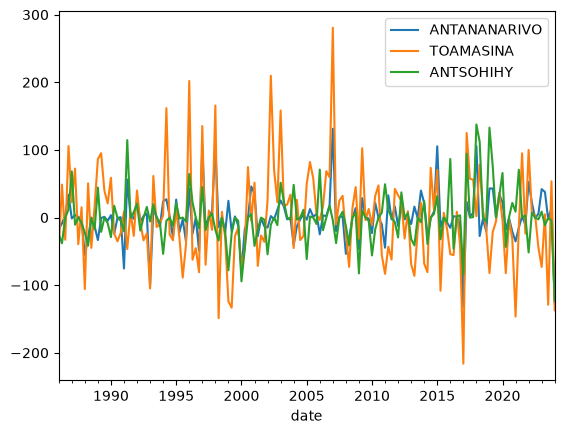

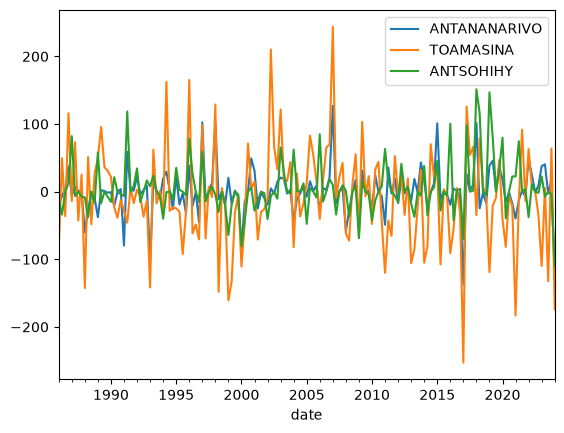

In [29]:
# calculating seasonal anomalies
#we need to create time series of seasonal values first
temp=temp=df.resample("QE-NOV").mean()

# and then we can use .transpose() and lambda function to calculate anomalies
anom_seas=temp.groupby(temp.index.month).transform(lambda x: x-x.mean())
anom_seas.plot()

# we can calcuate anomalies wrt. reference period too:
anom_seas=temp.groupby(temp.index.month).transform(lambda x: x-x["1990":"2010"].mean())
anom_seas.plot()

### Basic ploting framework

/tmp/ipykernel_50610/3077190987.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


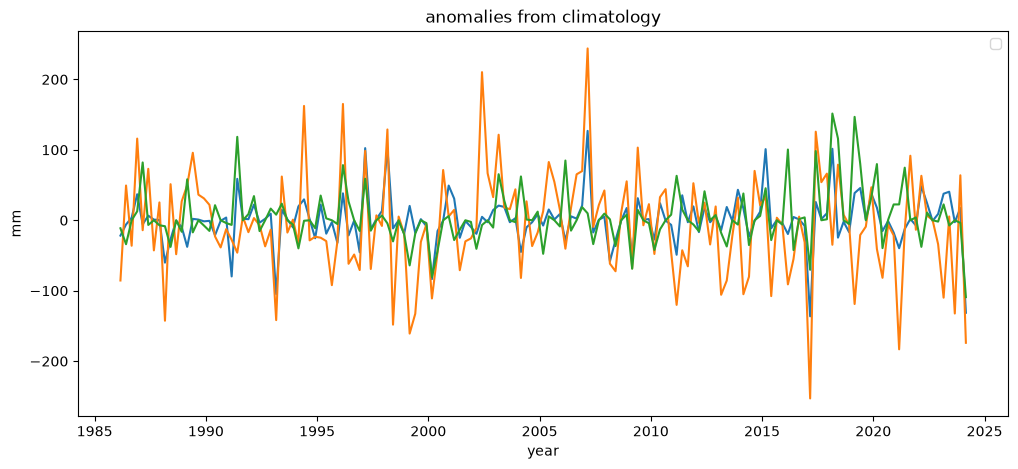

In [37]:
#importing plotting library
import matplotlib.pyplot as plt

#creating figure
fig=plt.figure(figsize=(12,5))

#creating panel
pl=fig.add_subplot(1,1,1)

#plotting actual plot into the panel
pl.plot(anom_seas)

#title
pl.set_title("anomalies from climatology")

#y axis label
pl.set_ylabel("mm")

#x axis label
pl.set_xlabel("year")

#plotting legend - nothing happens here because the pl.plot() does not fully recognize the properties of the plotted series
plt.legend()

#saving figure
plt.savefig("./test.jpg")

#showing plot in notebook - note that this has to be located AFTER save, otherwise figure is "closed" and save will save emtpy plot
plt.show()


---
## Exercises


### Tier 1 - Core

In [372]:
# 1. Read the rnino34.csv parsing index and dates, and explore what the data looks like


In [378]:
# 2. Plot Nino3.4 time series


In [6]:
# 3. extract and plot Nino3.4 for December only


In [386]:
# 4. plot Nino3.4 over the period after 2000 only


In [8]:
# 5. using December Nino data - change the date of data to start of the year


In [9]:
# 6. read the pr_mon_madagascar.csv data
#    using rainfall data - calculate and plot rainfall total for climatological year - Nov-Sep


### Tier 2 - Applications

In [387]:
# 1. Read rnino34.csv data. Extract months when there was an El Nino (rnino34>0.5).


In [384]:
# 2. Using rainfall data given above - calculate and plot annual anomalies from long-term mean


In [385]:
# 3. As above - but with reference period set to 1991-2020


In [ ]:
# 4. As above, but for climatological year - Nov-Sep


In [10]:
# 5. Calculate and plot climatological monthly minimum, mean and maximum of rainfall for Tana, using the 1991-2020 referece period


### Tier 3 - Advanced


In [11]:
# 1. Calculate the number of months for each year where nino34 is above 0.5 and create a bar graph of this per year. 
# Hint: to calculate yearly count - simply sum up boolean array values 
# Hint: Command for plotting a bar graph is df.plot(kind="bar") 


In [15]:
# 2. plot monthly rainfall data vs. monthlyt El Nino data
# hint: dataframes used in plt.plot(df1["v1"],"df2["v2"]) have to have identical dimensions and identical dates - 
# you have to subset both dataframes and align the dates


In [16]:
# 3. as above, but use climatological year rainfall total and ENSO status in December. 
